In [4]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('../hr_attrition.db')  # adjust path if your notebook is inside notebook/

In [5]:
query = "SELECT * FROM employees LIMIT 5;"
df_check = pd.read_sql_query(query, conn)
df_check

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
query1 = """
SELECT Attrition, COUNT(*) as count,
       ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM employees), 2) as percentage
FROM employees
GROUP BY Attrition;
"""
pd.read_sql_query(query1, conn)

,Attrition,count,percentage
0,No,1233,83.88
1,Yes,237,16.12


In [7]:
query2 = """
SELECT Department,
       COUNT(*) as total_employees,
       SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) as left_count,
       ROUND(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as attrition_rate
FROM employees
GROUP BY Department
ORDER BY attrition_rate DESC;
"""
pd.read_sql_query(query2, conn)

,Department,total_employees,left_count,attrition_rate
0,Sales,446,92,20.63
1,Human Resources,63,12,19.05
2,Research & Development,961,133,13.84


In [8]:
query3 = """
SELECT OverTime,
       COUNT(*) as total_employees,
       SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) as left_count,
       ROUND(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as attrition_rate
FROM employees
GROUP BY OverTime
ORDER BY attrition_rate DESC;
"""
pd.read_sql_query(query3, conn)

,OverTime,total_employees,left_count,attrition_rate
0,Yes,416,127,30.53
1,No,1054,110,10.44


In [9]:
query4 = """
SELECT 
    CASE 
        WHEN YearsAtCompany <= 2 THEN '0-2 years'
        WHEN YearsAtCompany <= 5 THEN '3-5 years'
        WHEN YearsAtCompany <= 10 THEN '6-10 years'
        ELSE '10+ years'
    END as tenure_bracket,
    COUNT(*) as total_employees,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) as left_count,
    ROUND(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as attrition_rate
FROM employees
GROUP BY tenure_bracket
ORDER BY attrition_rate DESC;
"""
pd.read_sql_query(query4, conn)

,tenure_bracket,total_employees,left_count,attrition_rate
0,0-2 years,342,102,29.82
1,3-5 years,434,60,13.82
2,6-10 years,448,55,12.28
3,10+ years,246,20,8.13


In [10]:
query5 = """
SELECT 
    CASE 
        WHEN Age < 25 THEN 'Under 25'
        WHEN Age < 35 THEN '25-34'
        WHEN Age < 45 THEN '35-44'
        ELSE '45+'
    END as age_bracket,
    COUNT(*) as total_employees,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) as left_count,
    ROUND(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as attrition_rate
FROM employees
GROUP BY age_bracket
ORDER BY attrition_rate DESC;
"""
pd.read_sql_query(query5, conn)

,age_bracket,total_employees,left_count,attrition_rate
0,Under 25,97,38,39.18
1,25-34,554,112,20.22
2,45+,314,36,11.46
3,35-44,505,51,10.10


In [11]:
df = pd.read_sql_query("SELECT * FROM employees", conn)
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\Hoysala\AppData\Local\Temp\ipykernel_11652\3439504082.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=attrition_by_overtime.index, y=attrition_by_overtime.values, palette='Set2')


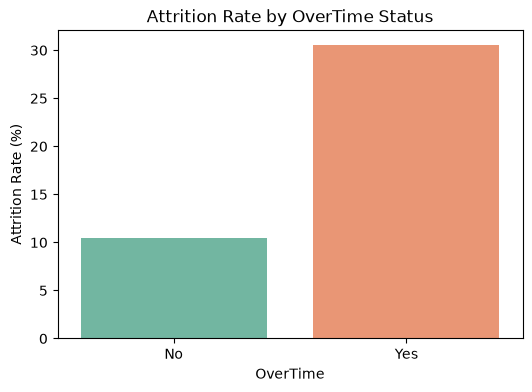

In [13]:
attrition_by_overtime = df.groupby('OverTime')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)

plt.figure(figsize=(6, 4))
sns.barplot(x=attrition_by_overtime.index, y=attrition_by_overtime.values, palette='Set2')
plt.title('Attrition Rate by OverTime Status')
plt.xlabel('OverTime')
plt.ylabel('Attrition Rate (%)')
plt.show()

C:\Users\Hoysala\AppData\Local\Temp\ipykernel_11652\1014662001.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=attrition_by_age.index, y=attrition_by_age.values, palette='Set2', order=age_labels)


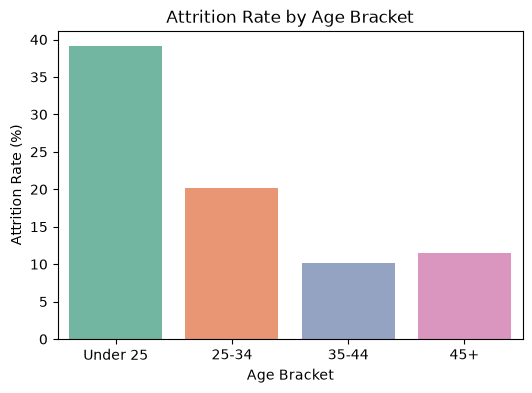

In [14]:
age_bins = [0, 25, 35, 45, 100]
age_labels = ['Under 25', '25-34', '35-44', '45+']
df['AgeBracket'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

attrition_by_age = df.groupby('AgeBracket')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)

plt.figure(figsize=(6, 4))
sns.barplot(x=attrition_by_age.index, y=attrition_by_age.values, palette='Set2', order=age_labels)
plt.title('Attrition Rate by Age Bracket')
plt.xlabel('Age Bracket')
plt.ylabel('Attrition Rate (%)')
plt.show()

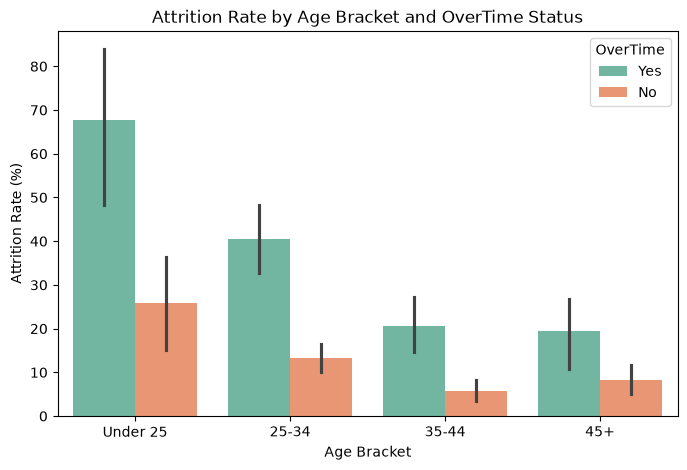

In [15]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='AgeBracket', y=(df['Attrition']=='Yes').astype(int)*100, hue='OverTime', order=age_labels, palette='Set2', estimator='mean')
plt.title('Attrition Rate by Age Bracket and OverTime Status')
plt.xlabel('Age Bracket')
plt.ylabel('Attrition Rate (%)')
plt.legend(title='OverTime')
plt.show()

In [16]:
features = ['Age', 'OverTime', 'MonthlyIncome', 'JobSatisfaction', 'YearsAtCompany', 'DistanceFromHome', 'Department']
target = 'Attrition'

model_df = df[features + [target]].copy()
model_df.head()

,Age,OverTime,MonthlyIncome,JobSatisfaction,YearsAtCompany,DistanceFromHome,Department,Attrition
0,41,Yes,5993,4,6,1,Sales,Yes
1,49,No,5130,2,10,8,Research & Development,No
2,37,Yes,2090,3,0,2,Research & Development,Yes
3,33,Yes,2909,3,8,3,Research & Development,No
4,27,No,3468,2,2,2,Research & Development,No


In [17]:
model_df['OverTime'] = model_df['OverTime'].map({'Yes': 1, 'No': 0})
model_df['Attrition'] = model_df['Attrition'].map({'Yes': 1, 'No': 0})
model_df.head()

,Age,OverTime,MonthlyIncome,JobSatisfaction,YearsAtCompany,DistanceFromHome,Department,Attrition
0,41,1,5993,4,6,1,Sales,1
1,49,0,5130,2,10,8,Research & Development,0
2,37,1,2090,3,0,2,Research & Development,1
3,33,1,2909,3,8,3,Research & Development,0
4,27,0,3468,2,2,2,Research & Development,0


In [18]:
model_df = pd.get_dummies(model_df, columns=['Department'], drop_first=True)
model_df.head()

,Age,OverTime,MonthlyIncome,JobSatisfaction,YearsAtCompany,DistanceFromHome,Attrition,Department_Research & Development,Department_Sales
0,41,1,5993,4,6,1,1,False,True
1,49,0,5130,2,10,8,0,True,False
2,37,1,2090,3,0,2,1,True,False
3,33,1,2909,3,8,3,0,True,False
4,27,0,3468,2,2,2,0,True,False


In [19]:
from sklearn.model_selection import train_test_split

X = model_df.drop('Attrition', axis=1)
y = model_df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape, X_test.shape)

(1176, 8) (294, 8)


In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Model trained successfully")

Model trained successfully


In [22]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      1.00      0.93       247
           1       0.91      0.21      0.34        47

    accuracy                           0.87       294
   macro avg       0.89      0.60      0.64       294
weighted avg       0.88      0.87      0.84       294

ROC-AUC Score: 0.7587216814540443
Confusion Matrix:
[[246   1]
 [ 37  10]]


In [23]:
model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
model_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = model_balanced.predict(X_test_scaled)
y_pred_proba_balanced = model_balanced.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_balanced))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba_balanced))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.92      0.72      0.81       247
           1       0.31      0.68      0.43        47

    accuracy                           0.71       294
   macro avg       0.62      0.70      0.62       294
weighted avg       0.82      0.71      0.75       294

ROC-AUC Score: 0.7609613231113791
Confusion Matrix:
[[177  70]
 [ 15  32]]
